# Problem 1
### (a)
LCG (Linear Congruential Generator) is a simple pseudo random number generator given as
$
\begin{gather}
    x'=(ax+c)\mod m~.
\end{gather}
$
Starting with the initial seed $x$, we get $x'$ using the above equation. Next, from the $x'$, we can get the next value $x''=(ax'+c)\mod m$. We can the find $x'''$ from $x''$ and continue this process. After enough iterations, the list $(x,x', x'',x''',\cdots)$ is sufficiently the list of random numbers.

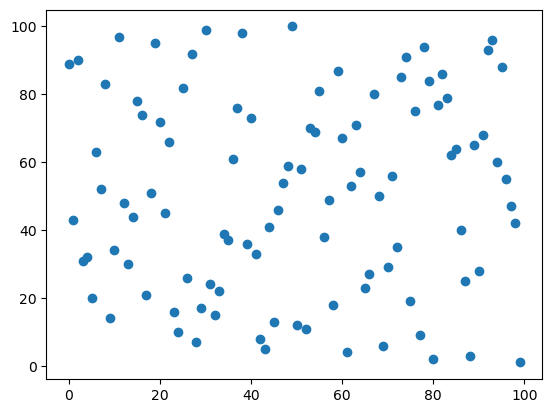

In [1]:
# (b)
import numpy as np
import matplotlib.pyplot as plt


def LCG(x, n, a, c, m, isNormalized=False):
    '''
    x: Initial seed
    n: length of random number list
    a, c, m: LCG parameters
    '''

    if isNormalized: 
        norm = m
        X = np.zeros((n), dtype=float)
        x /= norm
    else: 
        norm = 1
        X = np.zeros((n), dtype=int)

    for i in range(n):
        x = (a*x + c)%m
        X[i] = x/norm

    return X


r = LCG(1, 100, 89, 0, 101)
plt.plot(r, 'o')
plt.show()

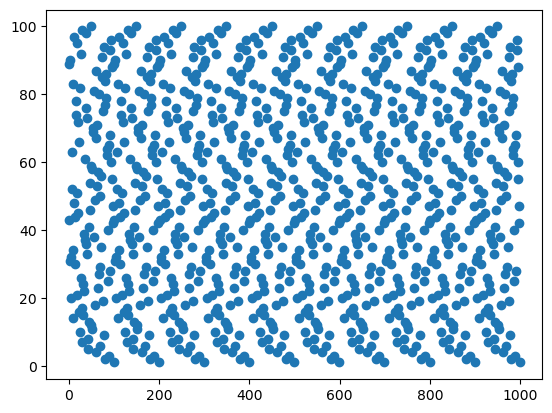

In [ ]:
# (c)

r = LCG(1, 1000, 89, 0, 101)
plt.plot(r, 'o')
plt.show()

We can find some patterns of random numbers

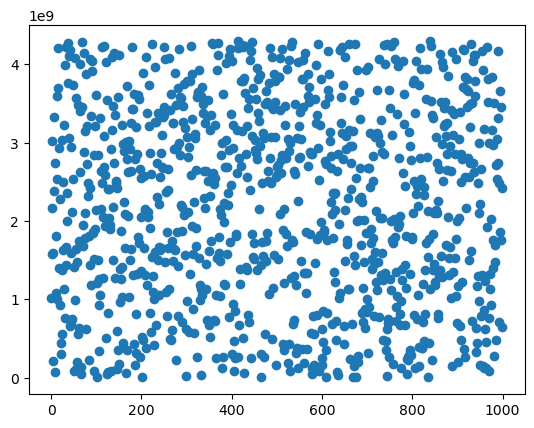

In [3]:
# (d)

r = LCG(1, 1000, 1664525, 1013904223, 4294967296)
plt.plot(r, 'o')
plt.show()

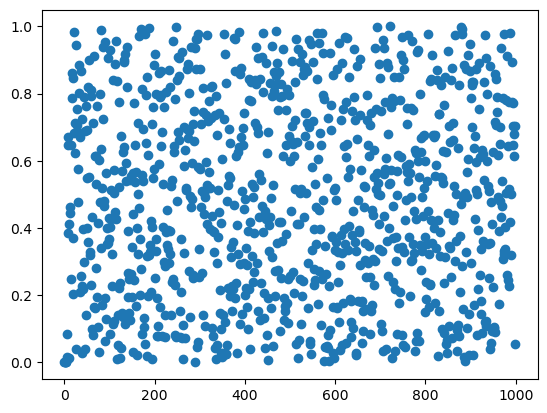

In [24]:
# (e): RANDU

r = LCG(0.5, 1000, 65539, 0, 2**31, isNormalized=True)
plt.plot(r, 'o')
plt.show()


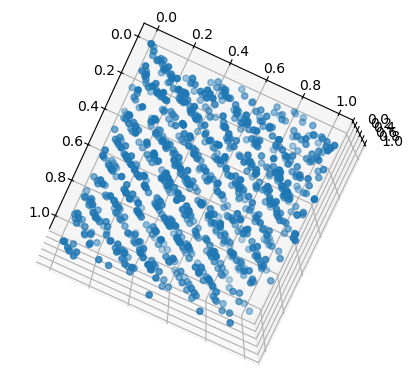

In [25]:
# (f)

n = len(r)
X = np.zeros((n-2, 3), dtype=float)

for i in range(n-2):
    X[i] = (r[i], r[i+1], r[i+2])

fig = plt.figure()
ax = plt.axes(projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2])
ax.view_init(elev=80, azim=-156, roll=179)
plt.show()


We can find that random numbers generated by RANDU is highly correlated: The random numbers are aligned in the parallel planes.

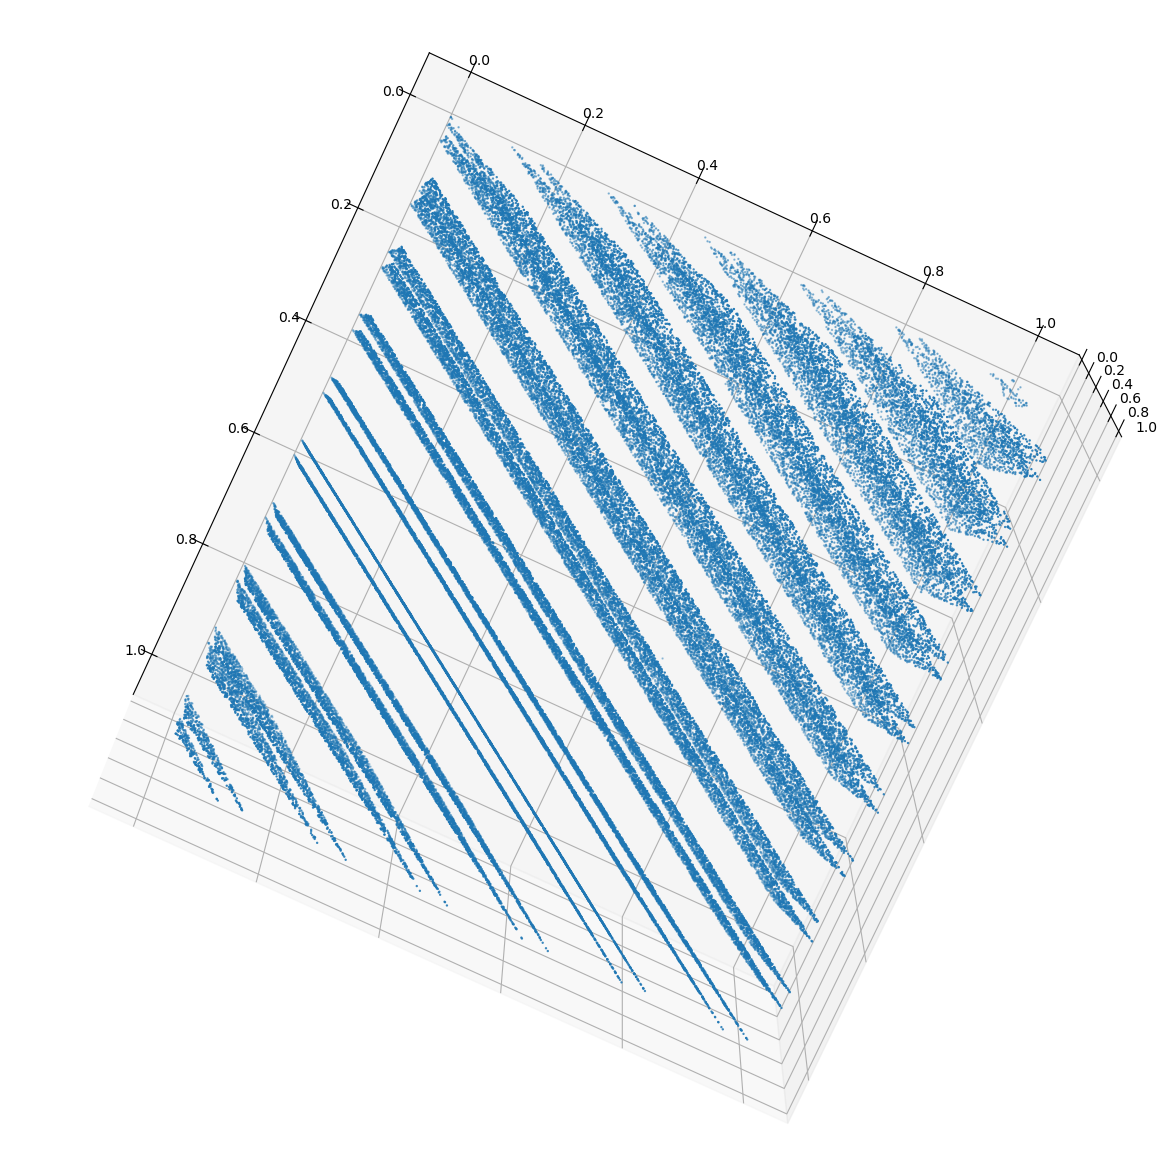

In [34]:
# (g)

r = LCG(0.5, 100000, 65539, 0, 2**31, isNormalized=True)
n = len(r)
X = np.zeros((n-2, 3), dtype=float)

for i in range(n-2):
    X[i] = (r[i], r[i+1], r[i+2])

fig = plt.figure(figsize=(15, 15))
ax = plt.axes(projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2], s=0.5)
ax.view_init(elev=80, azim=-156, roll=179)
plt.show()

## Problem 2

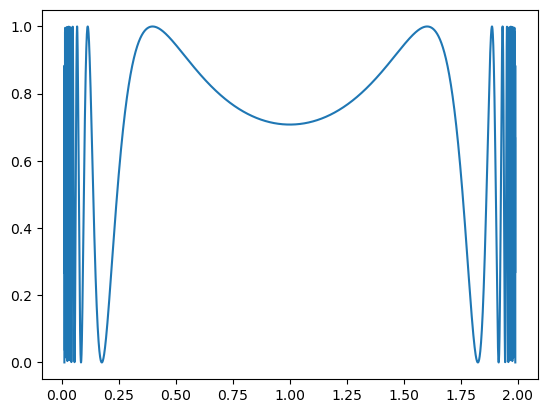

In [37]:
def f(x):
    # integrand
    # [0, 2]
    return np.sin(1/(x*(2-x)))**2


def Trapez(f, N, a, b):
    # Trapezoid method
    x = np.linspace(a, b, N + 1)
    h = (b - a)/N
    y = f(x)
    A = y[:-1] + y[1:]
    I = np.sum(A)*h*0.5

    return I


def Simpson(f, N, a, b):
    # Simpson's rule
    x = np.linspace(a, b, N + 1)
    h = (b - a)/N
    y = f(x)
    A = y[:-2:2] + y[2::2] + 4*y[1:-1:2]
    I = np.sum(A)*h/3

    return I


x = np.linspace(0.01, 1.99, 5000)
y = f(x)
plt.plot(x, y)
plt.show()

In [ ]:
# (a): Trapezoid rule

I = Trapez(f, 5000, 0, 2)